In [1]:
from typing import List
from copy import deepcopy
import itertools
import functools
from pathos.pools import ProcessPool as Pool
import numpy as np
import scipy.linalg as la
import matplotlib.pyplot as plt
import cirq
from encoded.repetition_code import (
    generate_stabilizers,
    encoding_repetition
)
from encoded.expanded_repetition_code import (
    x_bar,
    z_bar,
    stabilizer_generators,
    encoding_expanded_repetition,
    U_XXX
)
from encoded.symmetry_expansion import symmetry_expansion

In [2]:
def generate_stabilizer_elements(generators: List[cirq.PauliString]) -> List[cirq.PauliString]:
    elements = []
    for string in itertools.chain.from_iterable(itertools.combinations(generators, r) for r in range(len(generators) + 1)):
        elements.append(
            functools.reduce(lambda a, b: a * b, string, cirq.PauliString())
        )
    return elements

In [3]:
qubits = cirq.LineQubit.range(3)
n = 3
repetition_generators = []
for i in range(n-1):
    repetition_generators.append(cirq.Z.on(qubits[i]) * cirq.Z.on(qubits[i+1]))
repetition_elements = generate_stabilizer_elements(repetition_generators)
print(f"The group contains {len(repetition_elements)} elements:")
for element in repetition_elements:
    print(element)
repetition_qubits = deepcopy(qubits)

The group contains 4 elements:
I
Z(q(0))*Z(q(1))
Z(q(1))*Z(q(2))
Z(q(0))*Z(q(2))


In [4]:
def repetition_prep_circuit(psi_ckt: cirq.Circuit) -> cirq.Circuit:
    ckt = cirq.Circuit()
    ckt += psi_ckt
    ckt.append(cirq.CNOT(repetition_qubits[0], repetition_qubits[1]))
    ckt.append(cirq.CNOT(repetition_qubits[1], repetition_qubits[2]))
    return ckt

In [5]:
repetition_logical_z = cirq.Z.on(qubits[0])
repetition_logical_x = cirq.X.on(qubits[0]) * cirq.X.on(qubits[1]) * cirq.X.on(qubits[2])

In [6]:
qubits = cirq.LineQubit.range(4)
n = len(qubits)
extended_generators = stabilizer_generators
print(f"The group has {len(extended_generators)} generators:")
for generator in extended_generators:
    print(generator)
extended_elements = generate_stabilizer_elements(extended_generators)
print(f"The group contains {len(extended_elements)} elements:")
for element in extended_elements:
    print(element)
extended_qubits = deepcopy(qubits)

The group has 3 generators:
Z(q(0))*Z(q(1))
Z(q(1))*Z(q(2))
X(q(0))*X(q(1))*X(q(2))*X(q(3))
The group contains 8 elements:
I
Z(q(0))*Z(q(1))
Z(q(1))*Z(q(2))
X(q(0))*X(q(1))*X(q(2))*X(q(3))
Z(q(0))*Z(q(2))
-Y(q(0))*Y(q(1))*X(q(2))*X(q(3))
-X(q(0))*Y(q(1))*Y(q(2))*X(q(3))
-Y(q(0))*X(q(1))*Y(q(2))*X(q(3))


In [7]:
def extended_prep_circuit(psi_ckt: cirq.Circuit) -> cirq.Circuit:
    ckt = cirq.Circuit()
    ckt += psi_ckt
    ckt.append(cirq.CNOT(extended_qubits[0], extended_qubits[1]))
    ckt.append(cirq.CNOT(extended_qubits[1], extended_qubits[2]))
    ckt += U_XXX
    return ckt

In [8]:
# Prepare an even superposition of the |0> and |+> states.
q = qubits[0]
psi_prep_ckt = cirq.Circuit()
psi_prep_ckt.append(cirq.H(q))
psi_prep_ckt.append(cirq.Ry(rads=-np.pi/4).on(q))
print(psi_prep_ckt)
sim = cirq.Simulator()
result = sim.simulate(psi_prep_ckt)
psi = result.final_state_vector

plus_state = np.array([1., 1.]) / np.sqrt(2.)
zero_state = np.array([1., 0.])
target_state = plus_state + zero_state
target_state /= la.norm(target_state)
print(la.norm(target_state - psi))

0: ───H───Ry(-0.25π)───
4.5816625160956935e-08


In [9]:
exact_observable = cirq.PauliSum.from_pauli_strings([cirq.X.on(q), cirq.Z.on(q)])
exact_expectation_value = exact_observable.expectation_from_state_vector(psi, {q: 0})
print(f"Exact expectation: {exact_expectation_value}")

Exact expectation: (1.414213478565216+0j)


In [10]:
print(repetition_prep_circuit(psi_prep_ckt))
print(extended_prep_circuit(psi_prep_ckt))

0: ───H───Ry(-0.25π)───@───────
                       │
1: ────────────────────X───@───
                           │
2: ────────────────────────X───
0: ───H───Ry(-0.25π)───@───────H───@───H───────────
                       │           │
1: ────────────────────X───@───H───┼───@───H───────
                           │       │   │
2: ────────────────────────X───H───┼───┼───@───H───
                                   │   │   │
3: ────────────────────────────────X───X───X───H───


In [11]:
def run_repetition_code(noise_rate: float, noise_gate: cirq.Gate, reps=1, shots=None) -> float:
    """Get the error in the expectation value of logical X for a repetition code
    using subspace expansion."""

    circuit = cirq.Circuit()
    circuit += repetition_prep_circuit(psi_prep_ckt)
    for q in repetition_qubits:
        circuit.append(noise_gate(p=noise_rate).on(q))
    sim = cirq.DensityMatrixSimulator()

    def run_iteration(x):
        mitigated_exp_val = symmetry_expansion(
            circuit, repetition_logical_x + repetition_logical_z, repetition_elements, shots=shots, sim=sim
        )
        return mitigated_exp_val
    
    pool = Pool(8)
    exp_vals = pool.map(lambda x: run_iteration(x), range(reps))
    avg_err = np.average(np.abs(np.array(exp_vals) - exact_expectation_value))
    std_err = np.std(np.abs(np.array(exp_vals) - exact_expectation_value))
    return avg_err, std_err

In [12]:
def run_extended_code(noise_rate: float, ancilla_noise_rate: float, noise_gate: cirq.Gate, reps=1, shots=None, return_terms=False) -> float:
    """Get the error in the expectation value of logical X for a repetition code
    using subspace expansion."""

    circuit = cirq.Circuit()
    circuit += extended_prep_circuit(psi_prep_ckt)
    for i, q in enumerate(extended_qubits):
        if i != 3:
            circuit.append(noise_gate(p=noise_rate).on(q))
        else:
            circuit.append(noise_gate(p=ancilla_noise_rate).on(q))
    sim = cirq.DensityMatrixSimulator()

    def run_iteration(x):
        mitigated_exp_val = symmetry_expansion(circuit, x_bar + z_bar, extended_elements, shots=shots, sim=sim)
        return mitigated_exp_val
    
    pool = Pool(8)
    exp_vals = pool.map(lambda x: run_iteration(x), range(reps))
    avg_err = np.average(np.abs(np.array(exp_vals) - exact_expectation_value))
    std_err = np.std(np.abs(np.array(exp_vals) - exact_expectation_value))
    return avg_err, std_err

In [13]:
# Visualize the noise model
noise_rate = 0.1
ancilla_noise_rate = 1e-2
noise_gate = cirq.BitFlipChannel
circuit = cirq.Circuit()
circuit += extended_prep_circuit(psi_prep_ckt)
for i, q in enumerate(extended_qubits):
    if i != 3:
        circuit.append(noise_gate(p=noise_rate).on(q))
    else:
        circuit.append(noise_gate(p=ancilla_noise_rate).on(q))
print(circuit)

0: ───H───Ry(-0.25π)───@───────H───@───H───BF(0.1)────────────────────────
                       │           │
1: ────────────────────X───@───H───┼───@───H─────────BF(0.1)──────────────
                           │       │   │
2: ────────────────────────X───H───┼───┼───@─────────H─────────BF(0.1)────
                                   │   │   │
3: ────────────────────────────────X───X───X─────────H─────────BF(0.01)───


In [14]:
shots = None
reps = 10
# shots = 10_000
# reps = 20
noise_rates = np.linspace(1e-8, 1e-2, num=50)
noise_gates = [cirq.BitFlipChannel, cirq.PhaseFlipChannel, cirq.DepolarizingChannel]
noise_ratios = np.logspace(-4, 0, num=3) # Ancilla error probability / regular error probability

repetition_errs = np.zeros((len(noise_gates), len(noise_rates)))
extended_errs = np.zeros((len(noise_gates), len(noise_rates), len(noise_ratios)))
repetition_std = np.zeros((len(noise_gates), len(noise_rates)))
extended_std = np.zeros((len(noise_gates), len(noise_rates), len(noise_ratios)))

for i, gate in enumerate(noise_gates):
    for j, noise_rate in enumerate(noise_rates):
        err, std = run_repetition_code(noise_rate, gate, reps=reps, shots=shots)
        repetition_errs[i, j] = err
        repetition_std[i, j] = std
        for k, noise_ratio in enumerate(noise_ratios):
            err, std = run_extended_code(noise_rate, noise_ratio * noise_rate, gate, reps=reps, shots=shots)
            extended_errs[i, j, k] = err
            extended_std[i, j, k] = std

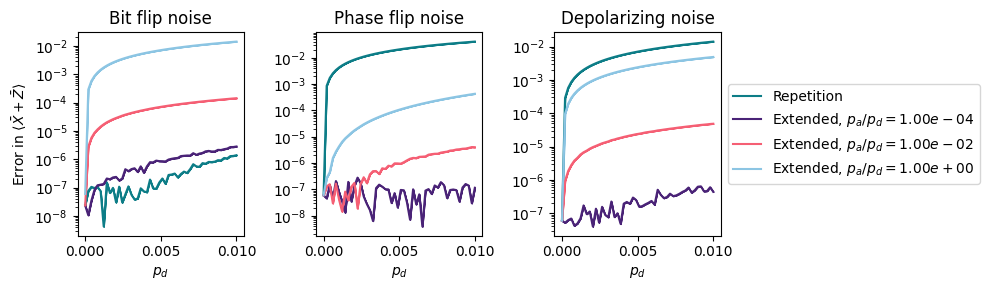

In [15]:
colors = ['#4a2377', '#f55f74', '#8cc5e3', "#0d7d87"]
fig, ax = plt.subplots(1, len(noise_gates), figsize=(10, 3))
for i in range(len(noise_gates)):
    ax[i].plot(noise_rates, repetition_errs[i, :], color=colors[-1], label="Repetition")
    ax[i].fill_between(
        noise_rates, repetition_errs[i, :] + repetition_std[i, :], repetition_errs[i, :] - repetition_std[i, :],
        color=colors[-1]
    )
    for j, ratio in enumerate(noise_ratios):
        ax[i].plot(noise_rates, extended_errs[i, :, j], color=colors[j], label=fr"Extended, $p_a/p_d={ratio:3.2e}$")
        ax[i].fill_between(
            noise_rates, extended_errs[i, :, j] + extended_std[i, :, j], extended_errs[i, :, j] - extended_std[i, :, j],
            color=colors[j]
        )
ax[len(noise_gates) - 1].legend(loc='center left', bbox_to_anchor=(1, 0.5))
for i in range(len(noise_gates)):
    ax[i].set_xlabel(r"$p_d$")
    ax[i].set_yscale('log')
ax[0].set_ylabel(r"Error in $\langle \bar{X} + \bar{Z} \rangle$")
ax[0].set_title("Bit flip noise")
ax[1].set_title("Phase flip noise")
ax[2].set_title("Depolarizing noise")
fig.tight_layout()

In [16]:
# shots = None
# reps = 10
shots = 100_000
reps = 20
noise_rates = np.linspace(1e-8, 1e-2, num=50)
noise_gates = [cirq.BitFlipChannel, cirq.PhaseFlipChannel, cirq.DepolarizingChannel]
noise_ratios = np.logspace(-4, 0, num=3) # Ancilla error probability / regular error probability

repetition_errs = np.zeros((len(noise_gates), len(noise_rates)))
extended_errs = np.zeros((len(noise_gates), len(noise_rates), len(noise_ratios)))
repetition_std = np.zeros((len(noise_gates), len(noise_rates)))
extended_std = np.zeros((len(noise_gates), len(noise_rates), len(noise_ratios)))

for i, gate in enumerate(noise_gates):
    for j, noise_rate in enumerate(noise_rates):
        err, std = run_repetition_code(noise_rate, gate, reps=reps, shots=shots)
        repetition_errs[i, j] = err
        repetition_std[i, j] = std
        for k, noise_ratio in enumerate(noise_ratios):
            err, std = run_extended_code(noise_rate, noise_ratio * noise_rate, gate, reps=reps, shots=shots)
            extended_errs[i, j, k] = err
            extended_std[i, j, k] = std

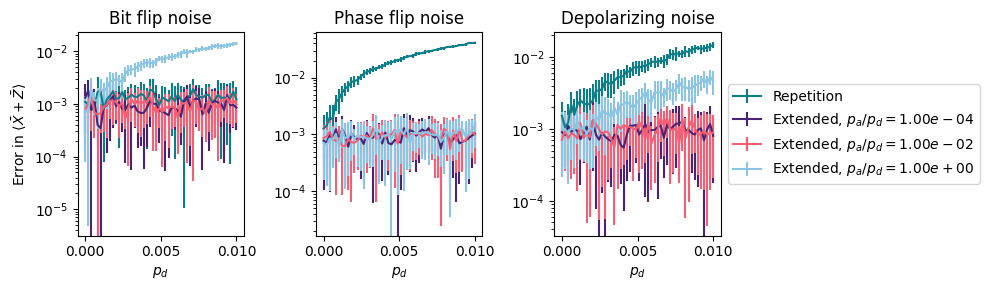

In [22]:
colors = ['#4a2377', '#f55f74', '#8cc5e3', "#0d7d87"]
fig, ax = plt.subplots(1, len(noise_gates), figsize=(10, 3))
for i in range(len(noise_gates)):
    ax[i].errorbar(noise_rates, repetition_errs[i, :], yerr=repetition_std[i, :], color=colors[-1], label="Repetition")
    # ax[i].fill_between(
    #     noise_rates, repetition_errs[i, :] + repetition_std[i, :], repetition_errs[i, :] - repetition_std[i, :],
    #     color=colors[-1], alpha=0.5
    # )
    for j, ratio in enumerate(noise_ratios):
        ax[i].errorbar(noise_rates, extended_errs[i, :, j], yerr=extended_std[i, :, j], color=colors[j], label=fr"Extended, $p_a/p_d={ratio:3.2e}$")
        # ax[i].fill_between(
        #     noise_rates, extended_errs[i, :, j] + extended_std[i, :, j], extended_errs[i, :, j] - extended_std[i, :, j],
        #     color=colors[j], alpha=0.5
        # )
ax[len(noise_gates) - 1].legend(loc='center left', bbox_to_anchor=(1, 0.5))
for i in range(len(noise_gates)):
    ax[i].set_xlabel(r"$p_d$")
    ax[i].set_yscale('log')
ax[0].set_ylabel(r"Error in $\langle \bar{X} + \bar{Z} \rangle$")
ax[0].set_title("Bit flip noise")
ax[1].set_title("Phase flip noise")
ax[2].set_title("Depolarizing noise")
fig.tight_layout()